In [1]:
# check installed version (must be >3.0)
import pycaret
pycaret.__version__

'3.3.2'

In [4]:
def clean_disp():
    res = pull()
    display(
        res.style
        .set_properties(**{
            "color": "#111",
            "background-color": "#fff"
        })
    )

# 🚀 Quick start

In [2]:
### load sample dataset from pycaret dataset module
from pycaret.datasets import get_data
data = get_data('insurance')

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Setup

Maximum One-Hot Encoding은 범주형 변수를 처리할 때 원-핫 인코딩(One-Hot Encoding)을 적용할 고유 값(unique values) 개수의 최대 임계치를 설정하는 기능

In [5]:
# import pycaret regression and init setup
from pycaret.regression import *
s = setup(data, target = 'charges', session_id = 123,verbose=False)
clean_disp()

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1338, 7)"
4,Transformed data shape,"(1338, 10)"
5,Transformed train set shape,"(936, 10)"
6,Transformed test set shape,"(402, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


## Compare Models

RMSLE (Root Mean Squared Logarithmic Error)**는 회귀 모델의 성능을 평가하는 지표 중 하나로, 예측값과 실제값에 **로그(Log)**를 취한 후 RMSE를 계산한 값

왜 RMSLE를 쓰나요? (주요 특징)
상대적 오차 중시 (Relative Error):
값의 절대적인 차이보다 비율을 중요하게 생각합니다. 예를 들어, 실제값이 10인데 20으로 예측한 것과, 실제값이 1,000인데 1,010으로 예측한 것 중 전자의 오차를 더 크게 반영합니다.
과소평가에 엄격함 (Penalty for Underestimation):
모델이 실제값보다 작게 예측했을 때(Underestimation) 더 큰 패널티를 부여합니다. 예를 들어, 배달 음식을 30분 걸린다고 했는데 40분 걸리는 것(과소평가)이 20분 걸리는 것(과대평가)보다 훨씬 치명적인 상황에 유용합니다.
Outlier(이상치)에 강함:
로그를 취하기 때문에 큰 수치들이 작게 압축됩니다. 따라서 아주 큰 이상치가 섞여 있어도 지표가 크게 휘둘리지 않습니다.

PyCaret에서의 활용
PyCaret의 회귀 모듈(pycaret.regression)에서 모델을 비교할 때 기본적으로 제공되는 지표 중 하나입니다. 주로 타겟 값의 범위가 크고 지수적인 증가를 보이는 데이터(예: 자전거 대여량 예측, 집값 예측 등)에서 자주 사용됩니다.

In [6]:
# compare baseline models
best = compare_models(verbose=False)
clean_disp()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2701.992700,23548981.362600,4832.968200,0.832000,0.444700,0.313700,0.033000
rf,Random Forest Regressor,2771.458300,25416502.382700,5028.634300,0.817200,0.469000,0.330300,0.066000
catboost,CatBoost Regressor,2899.378300,25762701.955200,5057.572100,0.816300,0.481500,0.352200,0.224000
lightgbm,Light Gradient Boosting Machine,2992.182800,25521038.333100,5042.097800,0.814900,0.537800,0.375100,0.414000
et,Extra Trees Regressor,2833.362400,28427844.241200,5305.651600,0.799100,0.487700,0.336300,0.055000
ada,AdaBoost Regressor,4316.056800,29220505.649800,5398.456100,0.790300,0.636800,0.739400,0.019000
xgboost,Extreme Gradient Boosting,3278.321600,31628234.000000,5599.098800,0.770900,0.573300,0.420800,0.036000
lr,Linear Regression,4303.555900,38388058.457800,6176.592000,0.730600,0.594900,0.443300,0.976000
br,Bayesian Ridge,4311.234900,38391950.087400,6176.889600,0.730600,0.591000,0.444700,0.014000
llar,Lasso Least Angle Regression,4303.769400,38386824.278600,6176.484600,0.730600,0.595200,0.443400,0.014000


## Analyze Model

The `plot_model` function is used to analyze the performance of a trained model on the test set. It may require re-training the model in certain cases.

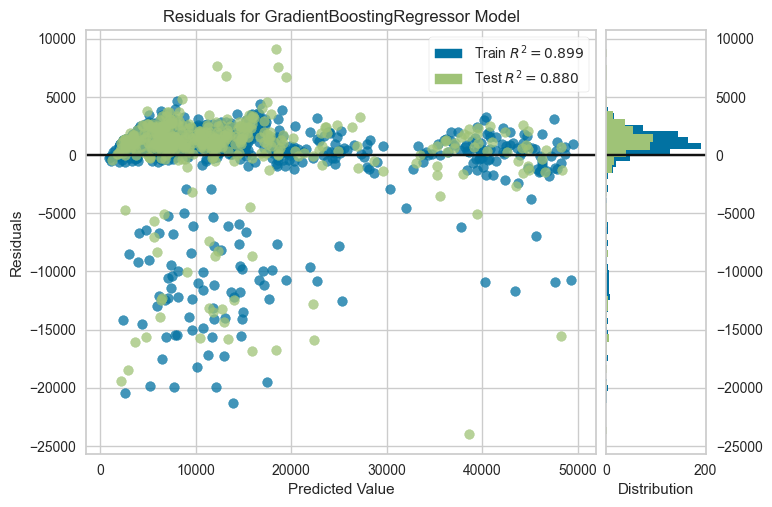

In [7]:
# plot residuals
plot_model(best, plot = 'residuals')

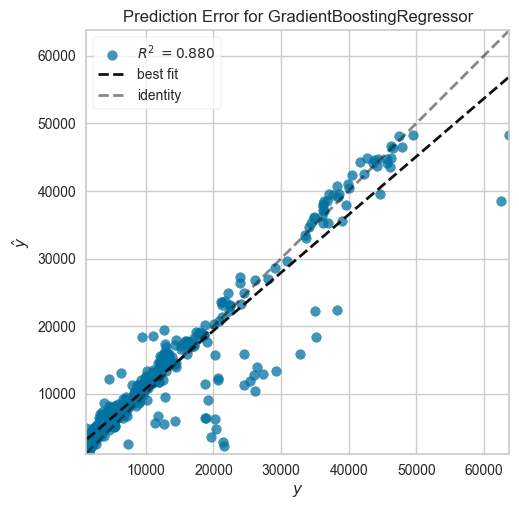

In [8]:
# plot error
plot_model(best, plot = 'error')

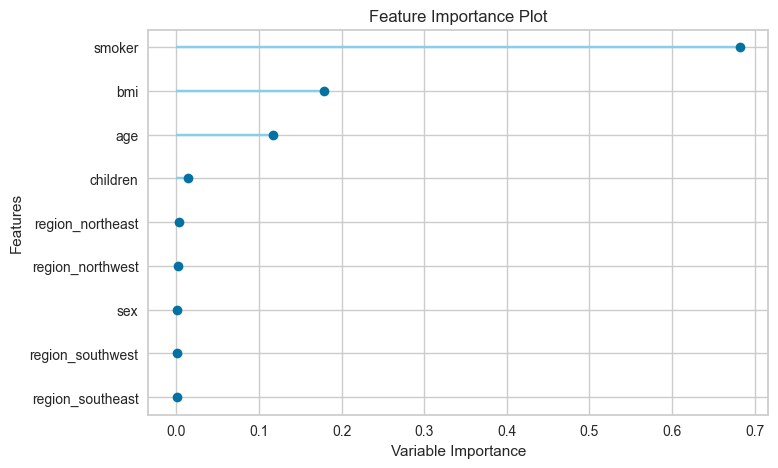

In [9]:
# plot feature importance
plot_model(best, plot = 'feature')

In [ ]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

___

## Prediction

In [11]:
# predict on test set
holdout_pred = predict_model(best)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,2392.5661,17148355.3169,4141.0573,0.8800,0.3928,0.2875


In [12]:
# show predictions df
holdout_pred.head()

,age,sex,bmi,children,smoker,region,charges,prediction_label
650,49,female,42.680000,2,no,southeast,9800.888672,10681.513104
319,32,male,37.334999,1,no,northeast,4667.607422,8043.453463
314,27,female,31.400000,0,yes,southwest,34838.871094,36153.097686
150,35,male,24.129999,1,no,northwest,5125.215820,7435.516853
336,60,male,25.740000,0,no,southeast,12142.578125,14676.544334


In [13]:
# copy data and drop charges

new_data = data.copy()
new_data.drop('charges', axis=1, inplace=True)
new_data.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [14]:
# predict model on new_data
predictions = predict_model(best, data = new_data)
predictions.head()

,age,sex,bmi,children,smoker,region,prediction_label
0,19,female,27.900000,0,yes,southwest,18464.334448
1,18,male,33.770000,1,no,southeast,4020.345384
2,28,male,33.000000,3,no,southeast,6555.388388
3,33,male,22.705000,0,no,northwest,9627.045725
4,32,male,28.879999,0,no,northwest,3325.531292


___

## Save Model

Finally, you can save the entire pipeline on disk for later use, using pycaret's `save_model` function.

In [15]:
# save pipeline
save_model(best, 'my_first_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['age', 'bmi', 'children'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['sex', 'smoker', 'region'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('ordinal_encoding',
                  TransformerWrapper(include=['sex', 'smoker'],
                                     transfor...
                                                                          'data_type': dtype('O'),
                                                                          'mapping': female    0
 male      1
 NaN      -1
 dtype: int64},
                                                                         {'col': 'smoker',
                                                                          'data_type': dtype(

In [16]:
# load pipeline
loaded_best_pipeline = load_model('my_first_pipeline')
loaded_best_pipeline

Transformation Pipeline and Model Successfully Loaded


Pipeline(memory=FastMemory(location=/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['age', 'bmi', 'children'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['sex', 'smoker', 'region'],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('ordinal_encodin...
                                                                         'data_type': dtype('O'),
                                                                         'mapping': female    0
male      1
NaN      -1
dtype: int64},
                                                                        {'col': 'smoker',
                                                                         'data_type': dtype('O'),
                                                                         'mapping': no     0
yes    1
NaN   -1
dtype: int64}]))),
                ('onehot_encoding',
                 TransformerWrapper(include=['region'],
                                    transformer=OneHotEncoder(cols=['region'],
                                                              handle_missing='return_nan',
                                                              use_cat_names=True))),
                ('trained_model', GradientBoostingRegressor(random_state=123))])

# 👇 Detailed function-by-function overview

## ✅ Setup

In [17]:
s = setup(data, target = 'charges', session_id = 123,verbose=False)
clean_disp()

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1338, 7)"
4,Transformed data shape,"(1338, 10)"
5,Transformed train set shape,"(936, 10)"
6,Transformed test set shape,"(402, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


In [18]:
# check all available config
get_config()

{'USI',
 'X',
 'X_test',
 'X_test_transformed',
 'X_train',
 'X_train_transformed',
 'X_transformed',
 '_available_plots',
 '_ml_usecase',
 'data',
 'dataset',
 'dataset_transformed',
 'exp_id',
 'exp_name_log',
 'fold_generator',
 'fold_groups_param',
 'fold_shuffle_param',
 'gpu_n_jobs_param',
 'gpu_param',
 'html_param',
 'idx',
 'is_multiclass',
 'log_plots_param',
 'logging_param',
 'memory',
 'n_jobs_param',
 'pipeline',
 'seed',
 'target_param',
 'test',
 'test_transformed',
 'train',
 'train_transformed',
 'transform_target_param',
 'variable_and_property_keys',
 'variables',
 'y',
 'y_test',
 'y_test_transformed',
 'y_train',
 'y_train_transformed',
 'y_transformed'}

In [19]:
# lets access X_train_transformed
get_config('X_train_transformed')

,age,sex,bmi,children,smoker,region_northeast,region_southwest,region_southeast,region_northwest
300,36.0,1.0,27.549999,3.0,0.0,1.0,0.0,0.0,0.0
904,60.0,0.0,35.099998,0.0,0.0,0.0,1.0,0.0,0.0
670,30.0,1.0,31.570000,3.0,0.0,0.0,0.0,1.0,0.0
617,49.0,1.0,25.600000,2.0,1.0,0.0,1.0,0.0,0.0
373,26.0,1.0,32.900002,2.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1238,37.0,1.0,22.705000,3.0,0.0,1.0,0.0,0.0,0.0
1147,20.0,0.0,31.920000,0.0,0.0,0.0,0.0,0.0,1.0
106,19.0,0.0,28.400000,1.0,0.0,0.0,1.0,0.0,0.0
1041,18.0,1.0,23.084999,0.0,0.0,1.0,0.0,0.0,0.0


In [20]:
# another example: let's access seed
print("The current seed is: {}".format(get_config('seed')))

# now lets change it using set_config
set_config('seed', 786)
print("The new seed is: {}".format(get_config('seed')))

The current seed is: 123
The new seed is: 786


In [21]:
# init setup with normalize = True
s = setup(data, target = 'charges', session_id = 123,
          normalize = True, normalize_method = 'minmax',verbose=False)
clean_disp()

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1338, 7)"
4,Transformed data shape,"(1338, 10)"
5,Transformed train set shape,"(936, 10)"
6,Transformed test set shape,"(402, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


<Axes: >

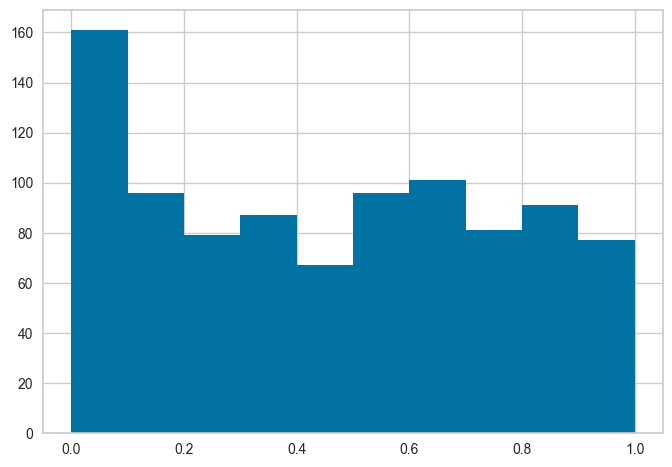

In [22]:
# lets check the X_train_transformed to see effect of params passed
get_config('X_train_transformed')['age'].hist()

<Axes: >

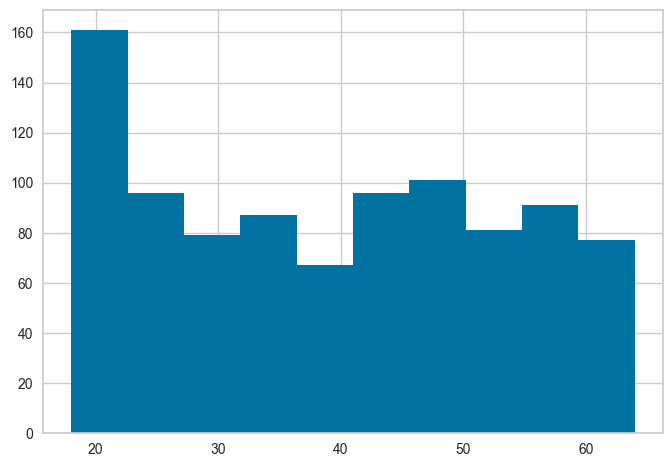

In [23]:
get_config('X_train')['age'].hist()

___

## ✅ Compare Models

In [25]:
best = compare_models(verbose=False)
clean_disp()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2701.914200,23548946.404700,4832.964300,0.832000,0.444700,0.313700,0.032000
rf,Random Forest Regressor,2772.919500,25409792.969200,5028.197300,0.817300,0.468700,0.329800,0.065000
catboost,CatBoost Regressor,2899.482500,25762752.209600,5057.577800,0.816300,0.481500,0.352200,0.353000
lightgbm,Light Gradient Boosting Machine,3001.888400,25547324.581300,5044.576700,0.814700,0.544500,0.378400,0.403000
et,Extra Trees Regressor,2833.362400,28427844.241200,5305.651600,0.799100,0.487700,0.336300,0.051000
ada,AdaBoost Regressor,4175.591600,28401799.057900,5321.700600,0.797600,0.626300,0.714400,0.018000
xgboost,Extreme Gradient Boosting,3278.321600,31628234.000000,5599.098800,0.770900,0.573300,0.420800,0.041000
lr,Linear Regression,4297.135900,38256939.304400,6166.459100,0.731400,0.599800,0.443300,0.888000
ridge,Ridge Regression,4296.064200,38392999.784900,6176.616000,0.730800,0.571000,0.439700,0.016000
br,Bayesian Ridge,4300.628600,38387539.906900,6176.419200,0.730700,0.588100,0.441900,0.015000


In [26]:
# check available models
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


You can use the `include` and `exclude` parameter in the `compare_models` to train only select model or exclude specific models from training by passing the model id's in `exclude` parameter.

In [28]:
compare_tree_models = compare_models(include = ['dt', 'rf', 'et', 'gbr', 'xgboost', 'lightgbm', 'catboost'],verbose=False)
clean_disp()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2701.914200,23548946.404700,4832.964300,0.832000,0.444700,0.313700,0.045000
rf,Random Forest Regressor,2772.919500,25409792.969200,5028.197300,0.817300,0.468700,0.329800,0.079000
catboost,CatBoost Regressor,2899.482500,25762752.209600,5057.577800,0.816300,0.481500,0.352200,0.218000
lightgbm,Light Gradient Boosting Machine,3001.888400,25547324.581300,5044.576700,0.814700,0.544500,0.378400,0.511000
et,Extra Trees Regressor,2833.362400,28427844.241200,5305.651600,0.799100,0.487700,0.336300,0.055000
xgboost,Extreme Gradient Boosting,3278.321600,31628234.000000,5599.098800,0.770900,0.573300,0.420800,0.069000
dt,Decision Tree Regressor,3399.140200,48100203.384700,6915.298400,0.647600,0.562900,0.405200,0.897000


In [29]:
compare_tree_models

GradientBoostingRegressor(random_state=123)

The function above has return trained model object as an output. The scoring grid is only displayed and not returned. If you need access to the scoring grid you can use `pull` function to access the dataframe.

In [30]:
compare_tree_models_results = pull()
compare_tree_models_results

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2701.9142,2.354895e+07,4832.9643,0.8320,0.4447,0.3137,0.045
rf,Random Forest Regressor,2772.9195,2.540979e+07,5028.1973,0.8173,0.4687,0.3298,0.079
catboost,CatBoost Regressor,2899.4825,2.576275e+07,5057.5778,0.8163,0.4815,0.3522,0.218
lightgbm,Light Gradient Boosting Machine,3001.8884,2.554732e+07,5044.5767,0.8147,0.5445,0.3784,0.511
et,Extra Trees Regressor,2833.3624,2.842784e+07,5305.6516,0.7991,0.4877,0.3363,0.055
xgboost,Extreme Gradient Boosting,3278.3216,3.162823e+07,5599.0988,0.7709,0.5733,0.4208,0.069
dt,Decision Tree Regressor,3399.1402,4.810020e+07,6915.2984,0.6476,0.5629,0.4052,0.897


By default `compare_models` return the single best performing model based on the metric defined in the `sort` parameter. Let's change our code to return 3 top models based on `MAE`.

In [31]:
best_mae_models_top3 = compare_models(sort = 'MAE', n_select = 3,verbose=False)
clean_disp()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2701.914200,23548946.404700,4832.964300,0.832000,0.444700,0.313700,0.033000
rf,Random Forest Regressor,2772.919500,25409792.969200,5028.197300,0.817300,0.468700,0.329800,0.091000
et,Extra Trees Regressor,2833.362400,28427844.241200,5305.651600,0.799100,0.487700,0.336300,0.094000
catboost,CatBoost Regressor,2899.482500,25762752.209600,5057.577800,0.816300,0.481500,0.352200,0.125000
lightgbm,Light Gradient Boosting Machine,3001.888400,25547324.581300,5044.576700,0.814700,0.544500,0.378400,0.378000
xgboost,Extreme Gradient Boosting,3278.321600,31628234.000000,5599.098800,0.770900,0.573300,0.420800,0.032000
dt,Decision Tree Regressor,3399.140200,48100203.384700,6915.298400,0.647600,0.562900,0.405200,0.030000
huber,Huber Regressor,3461.732700,49057640.561300,6981.857600,0.652800,0.481500,0.218800,0.038000
par,Passive Aggressive Regressor,3536.173300,48501878.136300,6940.196700,0.656600,0.478500,0.215400,0.051000
knn,K Neighbors Regressor,3778.458200,38143971.200000,6165.046300,0.727700,0.502700,0.369000,0.028000


In [32]:
# list of top 3 models by MAE
best_mae_models_top3

[GradientBoostingRegressor(random_state=123),
 RandomForestRegressor(n_jobs=-1, random_state=123),
 ExtraTreesRegressor(n_jobs=-1, random_state=123)]

## ✅ Create Model

In [34]:
# train linear regression with default fold=10
lr = create_model('lr',verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4224.319400,33778847.973900,5811.957300,0.798200,0.488600,0.433100
1,4553.039200,43216852.161100,6573.952600,0.748700,0.540400,0.438500
2,3853.037800,31981107.960200,5655.184200,0.595100,0.710800,0.439800
3,3707.770500,26513348.576000,5149.111400,0.778600,0.489100,0.516400
4,4484.212200,43828444.100000,6620.305400,0.674000,0.576100,0.384700
5,4113.622200,35882341.981000,5990.187100,0.769200,0.546400,0.413000
6,4063.482000,39360191.561500,6273.770100,0.732200,0.596600,0.420800
7,4833.774700,45739275.717200,6763.081800,0.748500,0.588700,0.396700
8,4621.061600,40681916.373700,6378.237700,0.737200,0.703200,0.522500


In [35]:
lr_results = pull()
print(type(lr_results))
lr_results

<class 'pandas.core.frame.DataFrame'>


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4224.3194,3.377885e+07,5811.9573,0.7982,0.4886,0.4331
1,4553.0392,4.321685e+07,6573.9526,0.7487,0.5404,0.4385
2,3853.0378,3.198111e+07,5655.1842,0.5951,0.7108,0.4398
3,3707.7705,2.651335e+07,5149.1114,0.7786,0.4891,0.5164
4,4484.2122,4.382844e+07,6620.3054,0.6740,0.5761,0.3847
5,4113.6222,3.588234e+07,5990.1871,0.7692,0.5464,0.4130
6,4063.4820,3.936019e+07,6273.7701,0.7322,0.5966,0.4208
7,4833.7747,4.573928e+07,6763.0818,0.7485,0.5887,0.3967
8,4621.0616,4.068192e+07,6378.2377,0.7372,0.7032,0.5225


In [36]:
# train linear regression with fold=3
lr = create_model('lr', fold=3,verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4468.677300,39314386.341500,6270.118500,0.719800,0.677400,0.515700
1,4242.803900,39312744.881300,6269.987600,0.720800,0.535000,0.431500
2,4517.343400,40759725.488500,6384.334400,0.749300,0.639600,0.438700
Mean,4409.608200,39795618.903800,6308.146800,0.730000,0.617400,0.462000
Std,119.610100,681726.633200,53.872700,0.013700,0.060200,0.038100


create_model('lr', fit_intercept = False)를 실행하면, y절편(intercept)을 0으로 고정한 선형 회귀 모델을 생성합니다.
주요 특징은 다음과 같습니다.

1. 동작 방식
선형 회귀('lr'): Scikit-Learn의 LinearRegression 알고리즘을 사용합니다.
fit_intercept = False: 모델이 데이터를 학습할 때 상수항(bias)을 계산하지 않도록 강제합니다. 즉, 회귀 직선이 반드시 원점(0, 0)을 지나게 됩니다.

2. 언제 사용하나요?
도메인 지식 반영: 모든 독립 변수(X)가 0일 때 종속 변수(y)도 반드시 0이어야 하는 논리적 근거가 있을 때 사용합니다. (예: 주택 면적이 0이면 가격도 0이다.)
모델 단순화: 파라미터(절편)를 하나 줄임으로써 모델을 더 단순하게 유지하고 싶을 때 사용합니다.

In [38]:
# train linear regression with specific model parameters
create_model('lr', fit_intercept = False,verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4222.961600,33775764.343200,5811.692000,0.798300,0.487900,0.432800
1,4522.581900,43620030.519200,6604.546200,0.746400,0.547300,0.421600
2,3853.037800,31981107.960200,5655.184200,0.595100,0.710800,0.439800
3,3707.770500,26513348.576000,5149.111400,0.778600,0.489100,0.516400
4,4484.212200,43828444.100000,6620.305400,0.674000,0.576100,0.384700
5,4113.622200,35882341.981000,5990.187100,0.769200,0.546400,0.413000
6,4098.086800,39631320.059800,6295.341100,0.730300,0.574500,0.426600
7,4833.774700,45739275.717200,6763.081800,0.748500,0.588700,0.396700
8,4621.061600,40681916.373700,6378.237700,0.737200,0.703200,0.522500


## ✅ Tune Model

In [40]:
# train a dt model with default params
dt = create_model('dt',verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3244.617300,45002914.997800,6708.421200,0.731200,0.588400,0.488300
1,3106.261100,45435728.753600,6740.603000,0.735800,0.538900,0.327100
2,3646.266200,54445682.262700,7378.731800,0.310700,0.647500,0.475200
3,3267.925000,45463401.774900,6742.655400,0.620400,0.575100,0.433900
4,4344.747000,65261429.301300,8078.454600,0.514600,0.726100,0.600800
5,3497.928100,42984919.025400,6556.288500,0.723500,0.461400,0.320800
6,3596.263700,53600704.729800,7321.250200,0.635300,0.528400,0.412600
7,2804.749300,37461859.854100,6120.609400,0.794000,0.473700,0.178700
8,3080.180100,42102090.884600,6488.612400,0.728100,0.516800,0.453700


In [41]:
# tune hyperparameters of dt
tuned_dt = tune_model(dt,verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1745.000800,18073621.253400,4251.308200,0.892000,0.340800,0.139000
1,2380.267100,33969297.497800,5828.318600,0.802500,0.480300,0.149100
2,2005.548100,23477540.527500,4845.362800,0.702700,0.474200,0.160400
3,1986.941900,22156779.863600,4707.098900,0.815000,0.373100,0.155000
4,2255.079700,28517151.438400,5340.145300,0.787900,0.483200,0.146500
5,1961.781000,20794913.660700,4560.144000,0.866200,0.365300,0.128700
6,1649.955900,20053618.609000,4478.126700,0.863500,0.331500,0.116400
7,2049.206600,26281892.467300,5126.586800,0.855500,0.465300,0.129800
8,1991.859900,23667668.439100,4864.942800,0.847100,0.386500,0.145200


In [42]:
dt

DecisionTreeRegressor(random_state=123)

In [45]:
# define tuning grid
dt_grid = {'max_depth' : [None, 2, 4, 6, 8, 10, 12]}

# tune model with custom grid and metric = MAE
tuned_dt = tune_model(dt, custom_grid = dt_grid, optimize = 'MAE',verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2862.168900,20651854.544000,4544.431200,0.876700,0.429100,0.337800
1,2985.548500,29278808.673600,5410.989600,0.829800,0.447100,0.301200
2,2843.367300,23854320.123800,4884.088500,0.698000,0.490000,0.362000
3,2868.125800,20204282.719900,4494.917400,0.831300,0.459700,0.410000
4,3153.215000,26237222.143200,5122.228200,0.804900,0.480100,0.341900
5,2735.182800,17885888.829200,4229.171200,0.884900,0.380600,0.291700
6,2606.728600,20086199.555300,4481.763000,0.863300,0.412400,0.336700
7,2831.025800,24114233.913800,4910.624600,0.867400,0.466400,0.333300
8,2663.457400,19629791.049000,4430.552000,0.873200,0.428800,0.365600


In [46]:
# model object
tuned_dt

DecisionTreeRegressor(max_depth=4, random_state=123)

## ✅ Ensemble Model

The `ensemble_model` function ensembles a given estimator. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [52]:
# ensemble with bagging
ensemble_model(dt, method = 'Bagging',verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2591.897000,23266281.457400,4823.513400,0.861000,0.463700,0.297600
1,2863.601700,30202461.814900,5495.676600,0.824400,0.488200,0.305300
2,2736.538000,24936511.932800,4993.647200,0.684300,0.514800,0.329300
3,2945.262600,27479881.326400,5242.125600,0.770500,0.516400,0.418700
4,3075.199000,30901342.431700,5558.897600,0.770200,0.567000,0.390600
5,2866.819800,25117097.449400,5011.696100,0.838400,0.371100,0.260700
6,2568.954500,22780849.685900,4772.928800,0.845000,0.373000,0.271700
7,2639.409100,26044331.107300,5103.364700,0.856800,0.471000,0.250600
8,2364.634300,19889092.442500,4459.718900,0.871500,0.410800,0.304000


In [53]:
# ensemble with boosting
ensemble_model(dt, method = 'Boosting',verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2054.766900,26692081.424800,5166.438000,0.840600,0.413100,0.193600
1,1991.329100,27836623.837000,5276.042400,0.838100,0.393300,0.119800
2,2577.520200,34350249.682000,5860.908600,0.565100,0.574800,0.323800
3,2408.344900,30508533.284200,5523.453000,0.745300,0.517200,0.378800
4,2564.692300,31138720.301200,5580.207900,0.768400,0.567800,0.302300
5,3145.562600,39513518.595000,6285.977900,0.745800,0.448100,0.282500
6,2069.453500,27352438.444300,5229.955900,0.813900,0.341200,0.142700
7,2125.269500,26494689.447500,5147.299200,0.854300,0.440300,0.157100
8,2053.831600,21762810.235600,4665.062700,0.859400,0.330700,0.174300


## ✅ Blend Models

The `blend_models` function trains a `VotingRegressor` for select models passed in the `estimator_list` parameter. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [54]:
# top 3 models based on mae
best_mae_models_top3

[GradientBoostingRegressor(random_state=123),
 RandomForestRegressor(n_jobs=-1, random_state=123),
 ExtraTreesRegressor(n_jobs=-1, random_state=123)]

In [55]:
# blend top 3 models
blend_models(best_mae_models_top3,verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2720.893400,22050841.610300,4695.832400,0.868300,0.463700,0.342500
1,2864.766500,30817703.762300,5551.369500,0.820800,0.453500,0.279900
2,2581.606700,22252661.301900,4717.272700,0.718300,0.546300,0.379400
3,2810.233300,21734211.356400,4661.996500,0.818500,0.486400,0.387300
4,3070.010300,30740150.246400,5544.380100,0.771400,0.546900,0.367900
5,2854.709700,22065332.313600,4697.375000,0.858100,0.377100,0.277800
6,2450.823800,20209907.991100,4495.543100,0.862500,0.374000,0.290100
7,2595.886800,23567769.102100,4854.664700,0.870400,0.399800,0.233500
8,2262.947700,18038706.997500,4247.199900,0.883500,0.384600,0.293700


## ✅ Stack Models

In [56]:
# stack models
stack_models(best_mae_models_top3,verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2643.164100,20511591.566000,4528.972500,0.877500,0.452500,0.340700
1,3017.312300,31626712.732700,5623.763200,0.816100,0.454100,0.297800
2,2540.310300,22023708.805600,4692.942400,0.721200,0.499400,0.327500
3,2939.770700,22184463.097800,4710.038500,0.814800,0.484400,0.393200
4,2921.036400,28216070.830000,5311.880200,0.790100,0.523100,0.348300
5,2675.011400,20116316.248000,4485.121700,0.870600,0.348600,0.252700
6,2359.583400,19851179.542300,4455.466300,0.864900,0.350400,0.263300
7,2594.781300,24555461.833900,4955.346800,0.865000,0.431200,0.266500
8,2225.841800,18029652.631200,4246.133800,0.883500,0.389100,0.294700


## ✅ Plot Model

The `plot_model` function analyzes the performance of a trained model on the hold-out set. It may require re-training the model in certain cases.

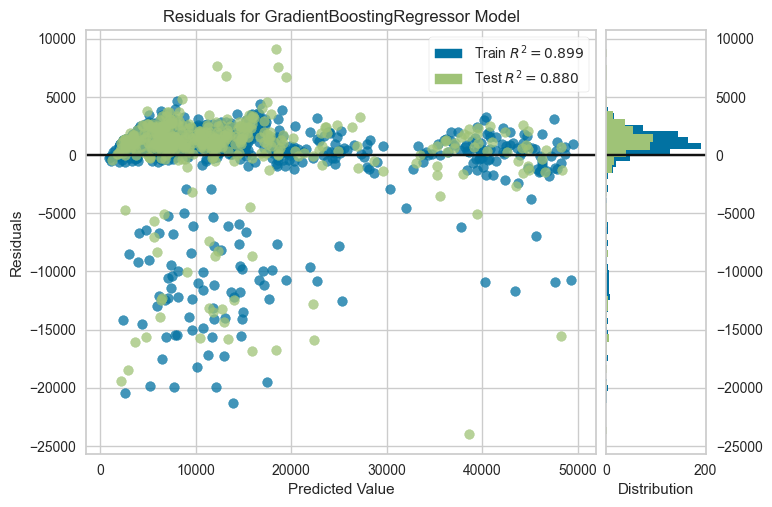

In [57]:
# plot residuals
plot_model(best, plot = 'residuals')

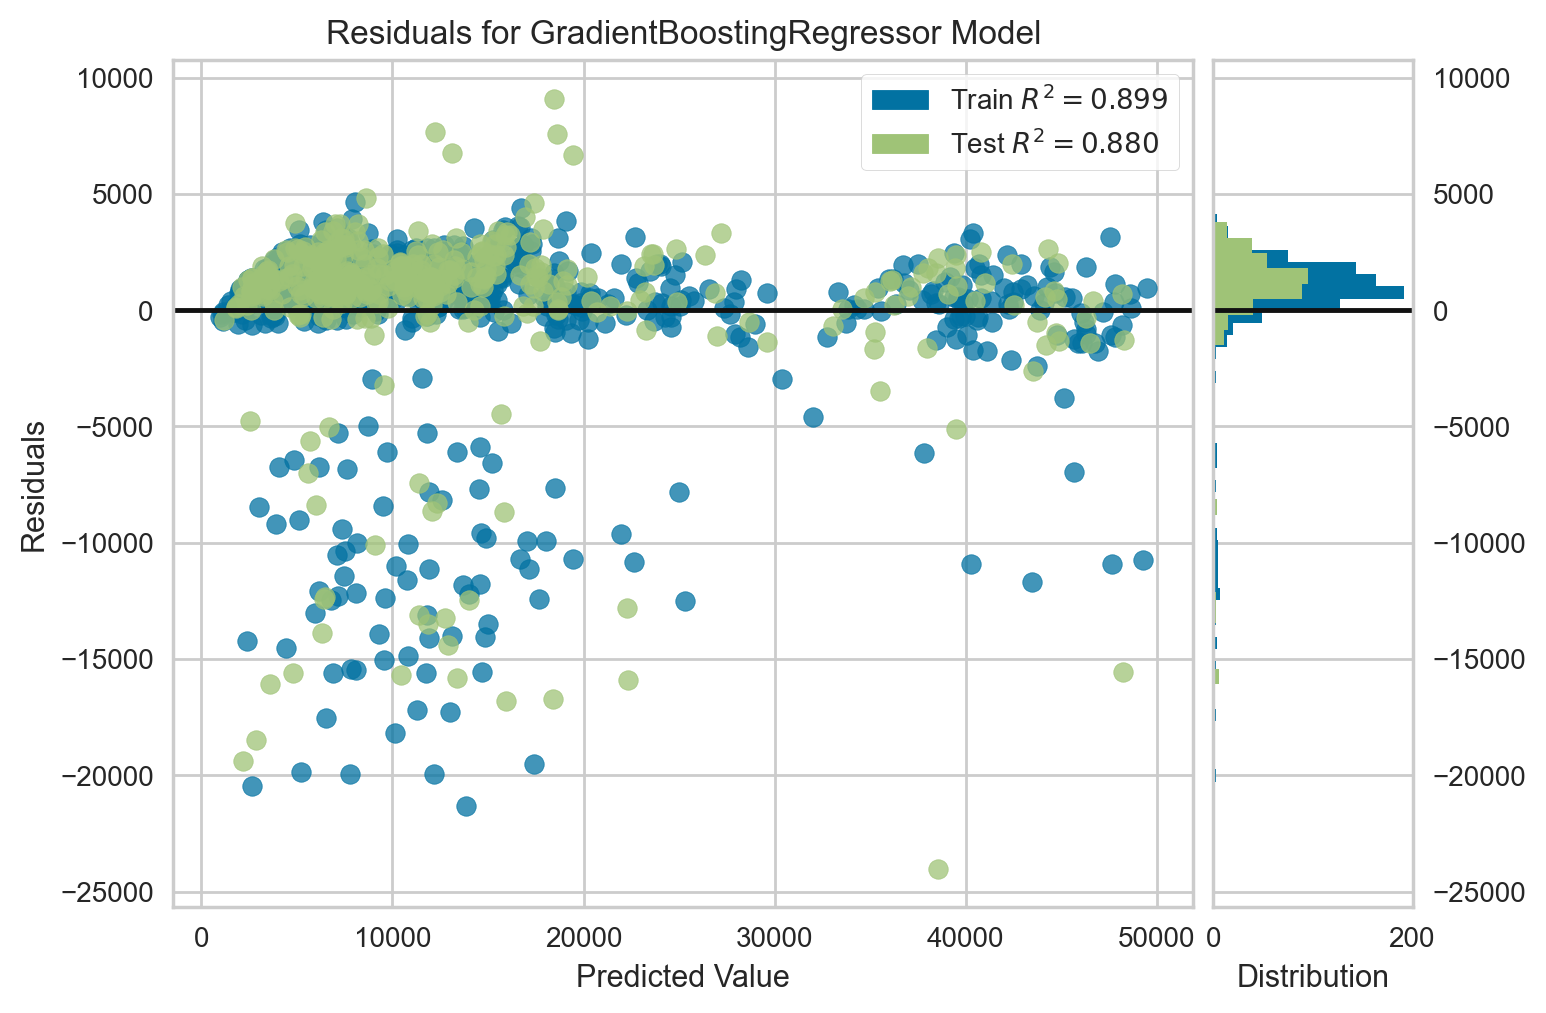

In [58]:
# to control the scale of plot
plot_model(best, plot = 'residuals', scale = 2)

In [59]:
# to save the plot
plot_model(best, plot = 'residuals', save=True)

'Residuals.png'

## ✅ Interpret Model

The `interpret_model` function analyzes the predictions generated from a trained model. Most plots in this function are implemented based on the SHAP (Shapley Additive exPlanations). For more info on this, please see https://shap.readthedocs.io/en/latest/

In [62]:
# train lightgbm model
lightgbm = create_model('lightgbm',verbose=False)
clean_disp()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2896.496400,23611929.401300,4859.210800,0.859000,0.599300,0.380800
1,3075.941900,30047230.748600,5481.535400,0.825300,0.462200,0.329500
2,3096.018500,27757739.187800,5268.561400,0.648600,0.615900,0.455000
3,3347.314400,26993115.824700,5195.490000,0.774600,0.810600,0.550900
4,3263.766000,29391206.784300,5421.365800,0.781400,0.562800,0.384600
5,2922.537200,21672554.759600,4655.379100,0.860600,0.417000,0.288100
6,2733.807100,21012815.386500,4583.973800,0.857000,0.399100,0.313900
7,2865.579600,25843408.713200,5083.641300,0.857900,0.502700,0.299500
8,2715.568000,21671018.592900,4655.214100,0.860000,0.523300,0.419200


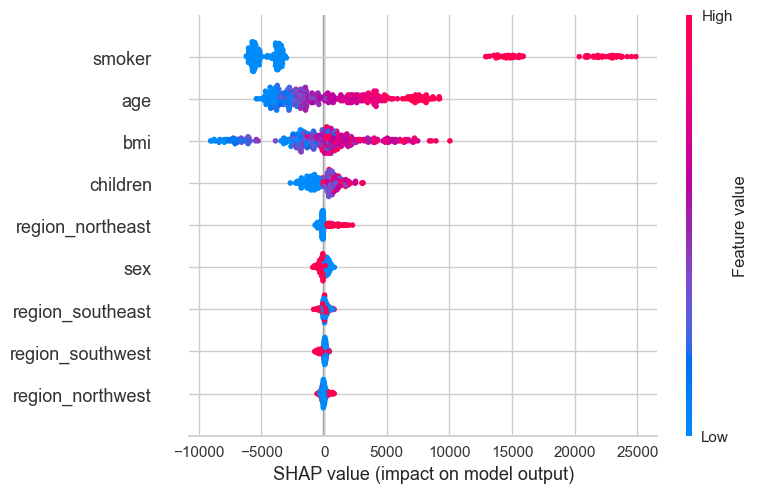

In [63]:
# interpret summary model
interpret_model(lightgbm, plot = 'summary')

In [71]:
get_config("X_test_transformed").head()

,age,sex,bmi,children,smoker,region_northeast,region_southwest,region_southeast,region_northwest
650,0.673913,0.0,0.723193,0.4,0.0,0.0,0.0,1.0,0.0
319,0.304348,1.0,0.573745,0.2,0.0,1.0,0.0,0.0,0.0
314,0.195652,0.0,0.407801,0.0,1.0,0.0,1.0,0.0,0.0
150,0.369565,1.0,0.204530,0.2,0.0,0.0,0.0,0.0,1.0
336,0.913043,1.0,0.249546,0.0,0.0,0.0,0.0,1.0,0.0


In [64]:
# reason plot for test set observation 1
interpret_model(lightgbm, plot = 'reason', observation = 1)

In [65]:
interpret_model(lightgbm, plot = 'reason', observation = 2)